shows minimum working example.

In [2]:
%load_ext autoreload
%autoreload 2
from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd
import numpy as np
from pathlib import Path
from src.data.preprocessor import read_smard_data

# Create dummy data

In [3]:
import numpy as np
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame

# Parameters
n_points = 20000
n_series = 3  # number of different time series
dates = pd.date_range("2024-01-01", periods=n_points, freq="D")

# Create sinusoidal patterns with noise for multiple series
dfs = []
for i in range(n_series):
    # different frequency & phase for each series
    freq = 0.1 + 0.05 * i
    phase = np.pi / 4 * i
    noise = np.random.normal(0, 0.7, size=n_points)

    values = np.sin(np.arange(n_points) * freq + phase) + noise

    df = pd.DataFrame({
        "item_id": i,
        "timestamp": dates,
        "target": values
    })
    dfs.append(df)

# Combine and convert to TimeSeriesDataFrame
data = TimeSeriesDataFrame.from_data_frame(pd.concat(dfs, ignore_index=True))

print(data.head(15))


                      target
item_id timestamp           
0       2024-01-01 -0.036906
        2024-01-02  1.144889
        2024-01-03  0.482054
        2024-01-04  0.736051
        2024-01-05  0.445294
        2024-01-06 -0.248454
        2024-01-07  0.611311
        2024-01-08  1.199799
        2024-01-09  1.013944
        2024-01-10 -0.936097
        2024-01-11  0.534399
        2024-01-12  1.374669
        2024-01-13 -0.218970
        2024-01-14 -0.046184
        2024-01-15  2.161922


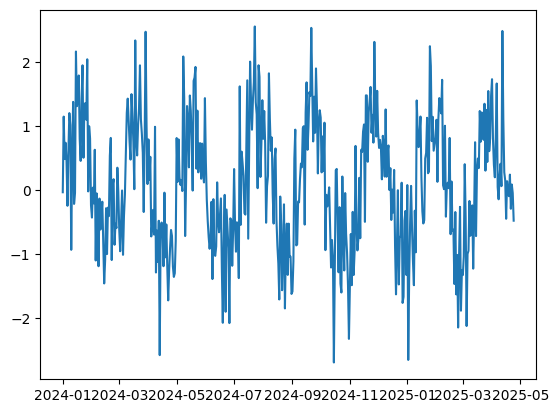

In [4]:
import matplotlib.pyplot as plt
# example time series
plt.plot(data.slice_by_timestep(end_index=480).loc[0])

In [5]:
# set frequency and quantiles
lead_times = np.arange(1, 480+1).tolist()
quantiles = np.arange(0.1,1,0.1).round(1).tolist()

## Minimum working example - Inference

In [6]:
from src.postprocessors.mle import PostprocessorMLE
from src.postprocessors.qr import PostprocessorFastQR
from src.postprocessors.eqc import PostprocessorEQC
from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos

/home/skowronek/.conda/envs/thesis/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2025-09-30 19:18:48,313 - INFO - config.py - PyTorch version 2.5.1 available.


In [7]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "cuda",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
    },
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 19:18:48,797 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 19:18:48,799 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 19:18:48,799 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


2025-09-30 19:18:49,533 - INFO - chronos.py - Using default schedule because head is resized.
2025-09-30 19:18:49,534 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → last_layer → full


In [ ]:
# make a zero shot forecast
forecasts = pipeline.generate_forecasts(data)

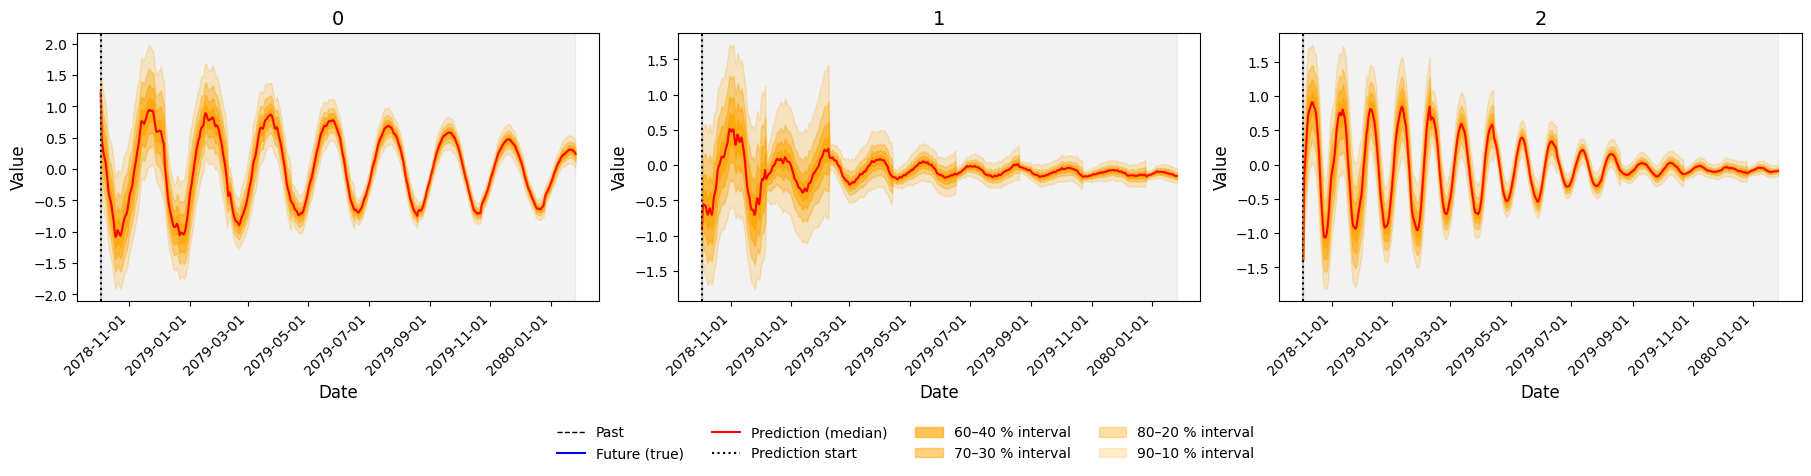

In [10]:
# variance collaps 
forecasts["Chronos-Bolt-tiny"].plot_forecasts()

In [11]:
# or conver to common forecasts
forecasts["Chronos-Bolt-tiny"].to_AutogluonFormat()

mean       0.1       0.2       0.3       0.4   
item_id timestamp                                                      
0       2078-10-04  0.508739 -0.352833 -0.051084  0.161149  0.339381  \
        2078-10-05  0.358713 -0.549945 -0.235615 -0.008875  0.182958   
        2078-10-06  0.250724 -0.657249 -0.339901 -0.116387  0.072835   
        2078-10-07  0.174100 -0.734981 -0.422040 -0.194767 -0.002972   
        2078-10-08  0.108016 -0.796136 -0.488132 -0.257706 -0.066474   
...                      ...       ...       ...       ...       ...   
2       2080-01-22 -0.100804 -0.174030 -0.136343 -0.120119 -0.109860   
        2080-01-23 -0.100287 -0.171843 -0.136047 -0.120290 -0.110173   
        2080-01-24 -0.096650 -0.168366 -0.128746 -0.115199 -0.105344   
        2080-01-25 -0.097064 -0.168130 -0.128891 -0.114648 -0.104777   
        2080-01-26 -0.091709 -0.169789 -0.129164 -0.111378 -0.100634   

                         0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                     
0       2078-10-04  0.508739  0.678782  0.866157  1.102993  1.457411  
        2078-10-05  0.358713  0.534207  0.724203  0.953621  1.302216  
        2078-10-06  0.250724  0.425390  0.617640  0.849074  1.188323  
        2078-10-07  0.174100  0.345254  0.538414  0.767917  1.097484  
        2078-10-08  0.108016  0.283575  0.476395  0.700938  1.034536  
...                      ...       ...       ...       ...       ...  
2       2080-01-22 -0.100804 -0.090444 -0.075966 -0.056676 -0.011713  
        2080-01-23 -0.100287 -0.090034 -0.077169 -0.057342 -0.016953  
        2080-01-24 -0.096650 -0.088197 -0.074468 -0.054205 -0.011211  
        2080-01-25 -0.097064 -0.088266 -0.074962 -0.056459 -0.013753  
        2080-01-26 -0.091709 -0.082754 -0.069327 -0.049782 -0.007425  

[1440 rows x 10 columns]

# Fine-tune Chronos on extended prediction length

In [12]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "cuda",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
        "finetuning_schedule": ["Full"], # other fine-tunings possible
        "finetuning_adjust_pretrained_prediction_length": True,
        "finetuning_warmup_new_neurons": True,
    },
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 19:19:22,192 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 19:19:22,193 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 19:19:22,194 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-30 19:19:22,774 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 19:19:22,775 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full


In [ ]:
# just select a subset for training
data_train = data.slice_by_timestep(end_index=-1000)
data_val = data.slice_by_timestep(start_index=-1000)

In [16]:
pipeline.train_predictor_model(data_train=data_train, data_val=data_val, train_window_step=1)

2025-09-30 19:19:44,579 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-09-30 19:19:44,580 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 19:19:44,581 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 19:19:44,582 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny


2025-09-30 19:19:45,143 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 19:19:45,144 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full
2025-09-30 19:19:45,145 - INFO - pipeline.py - Validation data is provided.
2025-09-30 19:19:45,149 - INFO - pipeline.py - Training data from 2024-01-01 00:00:00 to 2076-01-07 00:00:00
2025-09-30 19:19:45,151 - INFO - pipeline.py - Validation data from 2076-01-08 00:00:00 to 2077-05-21 00:00:00
2025-09-30 19:19:45,152 - INFO - pipeline.py - Fitting predictor to the training data...
2025-09-30 19:19:45,152 - INFO - chronos.py - Prediction length will be set to 480 during training.
2025-09-30 19:19:45,154 - INFO - chronos.py - Setting train stride: 1, validation stride: 480
2025-09-30 19:19:45,154 - INFO - chronos.py - Preparing training dataset...
2025-09-30 19:19:45,181 - INFO - chronos.py - train dataset samples: 56280
2025-09-30 19:19:45,182 - INFO - chronos.py - Preparing validation dataset.

{'eval_loss': 313.4402770996094, 'eval_runtime': 0.2335, 'eval_samples_per_second': 12.85, 'eval_steps_per_second': 4.283, 'epoch': 0}


Could not estimate the number of tokens of the input, floating-point operations will not be computed


{'loss': 300.6708, 'grad_norm': 15.951495170593262, 'learning_rate': 9.888636363636364e-05, 'epoch': 0.22727272727272727}
{'loss': 261.6308, 'grad_norm': 9.966293334960938, 'learning_rate': 9.775e-05, 'epoch': 0.45454545454545453}


...

2025-09-30 19:22:54,364 - INFO - chronos.py - New best @ step 400: eval_loss=205.3450, marking .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_1_full/training/checkpoint-400


{'eval_loss': 205.3450164794922, 'eval_runtime': 0.2582, 'eval_samples_per_second': 11.62, 'eval_steps_per_second': 3.873, 'epoch': 1.8181818181818183}
{'loss': 210.1708, 'grad_norm': 34.28414535522461, 'learning_rate': 8.979545454545455e-06, 'epoch': 2.0454545454545454}
{'loss': 209.9176, 'grad_norm': 27.999332427978516, 'learning_rate': 8.865909090909092e-06, 'epoch': 2.2727272727272725}
{'eval_loss': 205.5300750732422, 'eval_runtime': 0.2392, 'eval_samples_per_second': 12.544, 'eval_steps_per_second': 4.181, 'epoch': 2.2727272727272725}
{'loss': 209.3314, 'grad_norm': 29.519495010375977, 'learning_rate': 8.752272727272728e-06, 'epoch': 2.5}
{'loss': 209.5249, 'grad_norm': 37.44831466674805, 'learning_rate': 8.638636363636364e-06, 'epoch': 2.7272727272727275}
{'eval_loss': 205.66583251953125, 'eval_runtime': 0.248, 'eval_samples_per_second': 12.098, 'eval_steps_per_second': 4.033, 'epoch': 2.7272727272727275}
{'loss': 209.0566, 'grad_norm': 31.58548355102539, 'learning_rate': 8.525e-

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


{'eval_loss': 205.88427734375, 'eval_runtime': 0.2418, 'eval_samples_per_second': 12.409, 'eval_steps_per_second': 4.136, 'epoch': 4.090909090909091}
{'train_runtime': 75.5017, 'train_samples_per_second': 14908.268, 'train_steps_per_second': 58.277, 'train_loss': 211.36054036458333, 'epoch': 4.090909090909091}


2025-09-30 19:23:36,300 - INFO - chronos.py - Saved fine-tuned model to .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_1_full/fine-tuned-ckpt.
2025-09-30 19:23:36,742 - INFO - chronos.py - Loading Chronos pipeline from model: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_1_full/fine-tuned-ckpt
2025-09-30 19:23:36,743 - INFO - chronos.py - Initializing Chronos pipeline with model: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny/stage_1_full/fine-tuned-ckpt
2025-09-30 19:23:36,799 - INFO - chronos.py - Fine-tuning completed – model reloaded.
2025-09-30 19:23:36,800 - INFO - base.py - Time to fit Chronos in seconds: 231.65


In [17]:
# make forecasts with fine tuned model
forecasts = pipeline.generate_forecasts(data)

2025-09-30 19:24:36,579 - INFO - pipeline.py - Starting forecast generation of model Chronos-Bolt-tiny for data_test from 2024-01-01 00:00:00 to 2078-10-03 00:00:00


Predicting using Chronos:   0%|          | 0/1 [00:00<?, ?it/s]

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/home/skowronek/.local/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "/home/skowronek/.conda/envs/thesis/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)

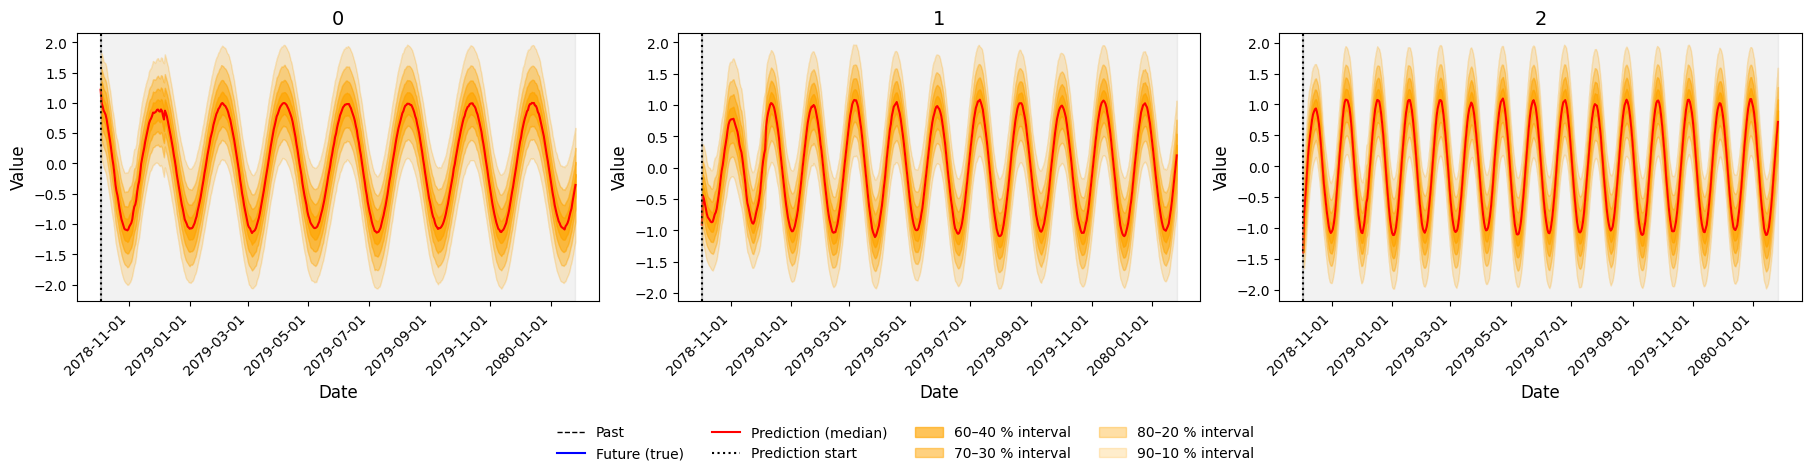

In [18]:
forecasts["Chronos-Bolt-tiny"].plot_forecasts()

# Postprocess zero-shot forecasts

In [19]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "cuda",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
        "finetuning_schedule": ["Full"],
        "finetuning_adjust_pretrained_prediction_length": True,
        "finetuning_warmup_new_neurons": True,
    },
    postprocessors=[PostprocessorFastQR, PostprocessorEQC],
    postprocessor_kwargs=[{"name": "LinQC", "n_jobs": 4}, {"name": "ConQC","n_jobs": 4}],
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 19:24:54,352 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 19:24:54,353 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 19:24:54,354 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-30 19:24:54,948 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 19:24:54,949 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full
2025-09-30 19:24:54,950 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 19:24:54,951 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC


In [20]:
# generate calibration forecasts and train postprocessor
calibration_forecasts = pipeline.auto_generate_calibration_forecasts(data, max_calibration_samples=200)
pipeline.train_postprocessors(calibration_forecasts["Chronos-Bolt-tiny"])

2025-09-30 19:24:59,192 - WARNING - pipeline.py - Using sampling_method='fixed_stride'. Note: if prediction_length << seasonality and max_calibration_samples is small, calibration coverage may be poor. Consider sampling_method='random' instead. TODO: add option to account for seasonality when selecting calibration samples.
2025-09-30 19:24:59,194 - INFO - pipeline.py - Calibration samples per time series: {0: 161, 1: 161, 2: 161}
2025-09-30 19:24:59,196 - INFO - pipeline.py - Starting forecast generation of model Chronos-Bolt-tiny for data_test from 2024-01-01 00:00:00 to 2078-10-03 00:00:00


Predicting using Chronos:   0%|          | 0/4 [00:00<?, ?it/s]

/home/skowronek/master-thesis/chronos-forecasting/src/chronos/chronos_bolt.py:627: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)
2025-09-30 19:25:20,366 - INFO - base.py - Chronos: Time to generate forecasts in seconds: 21.17
2025-09-30 19:25:20,368 - INFO - pipeline.py - Start training postprocessors...
2025-09-30 19:25:20,370 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 19:25:20,371 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC
Fitting LinQC for each time series (item):   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

2025-09-30 19:25:22,569 - INFO - base.py - Time to fit LinQC in seconds: 2.2


  0%|          | 0/3 [00:00<?, ?it/s]

Fitting LinQC for each time series (item):   0%|          | 0/3 [00:02<?, ?it/s]
2025-09-30 19:25:26,292 - INFO - base.py - Time to fit ConQC in seconds: 3.72
2025-09-30 19:25:26,293 - INFO - pipeline.py - Postprocessors training completed in 5.9239 seconds.


In [ ]:
# make final predictions
forecasts = pipeline.generate_forecasts(data)
forecasts = pipeline.apply_postprocessors_to_forecasts(forecasts)

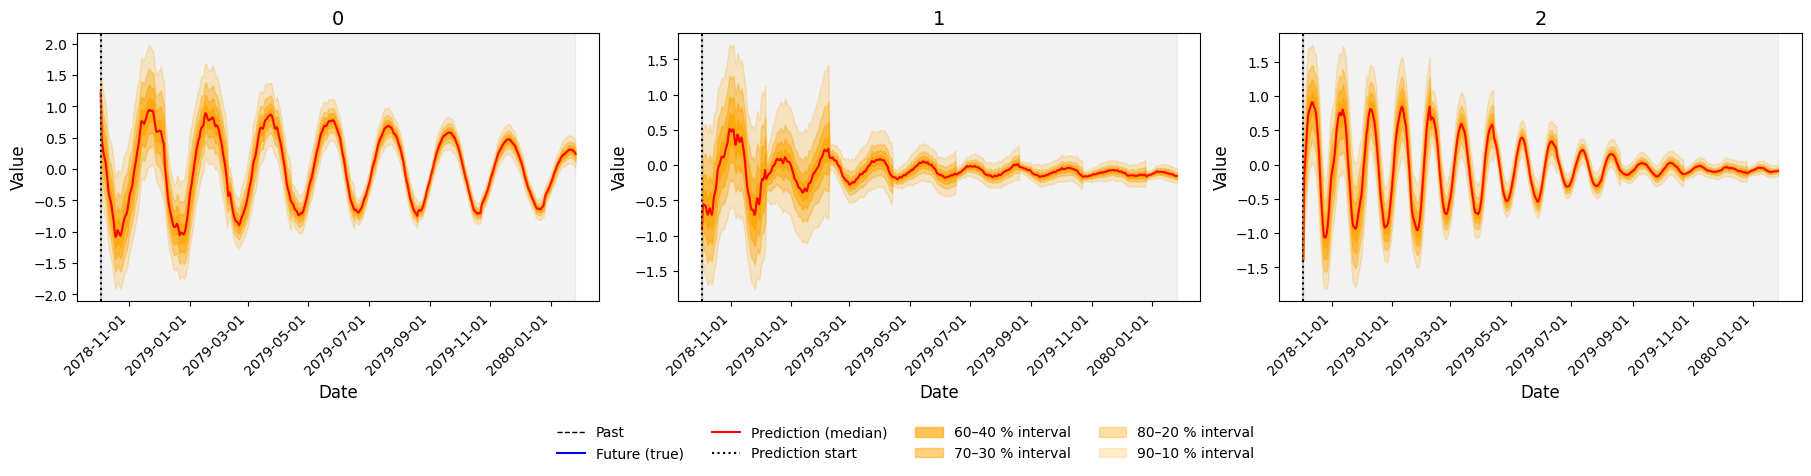

In [23]:
forecasts["Chronos-Bolt-tiny"].plot_forecasts()

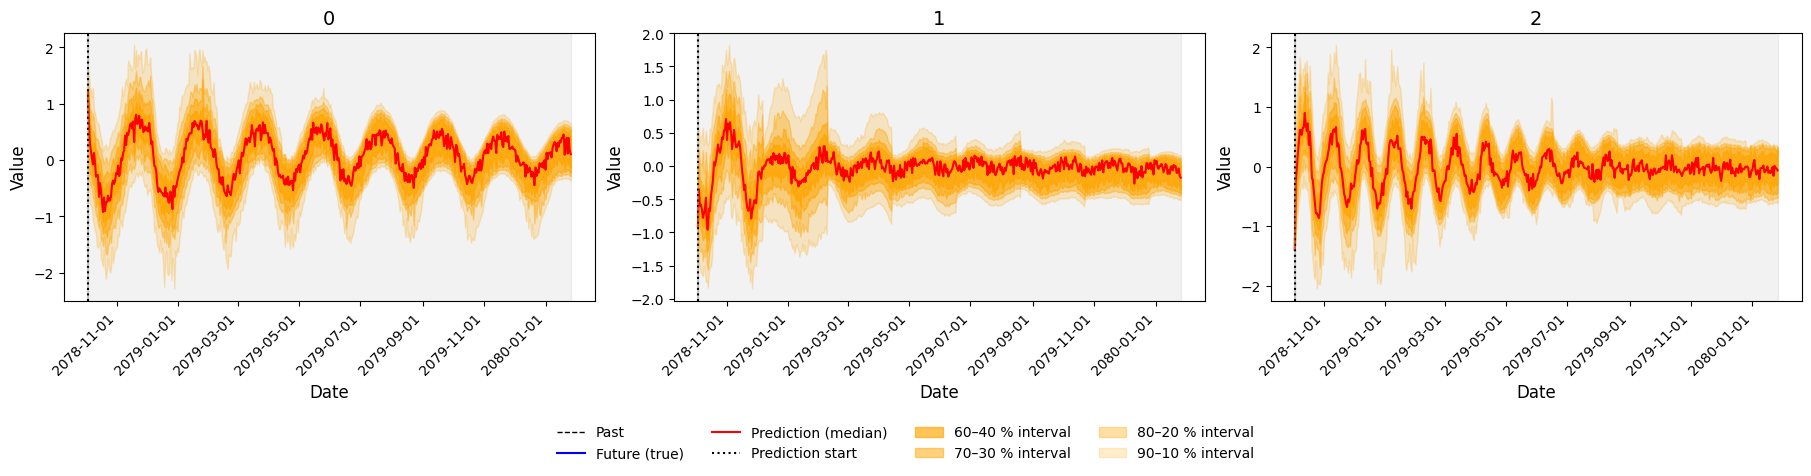

In [24]:
forecasts["LinQC"].plot_forecasts()

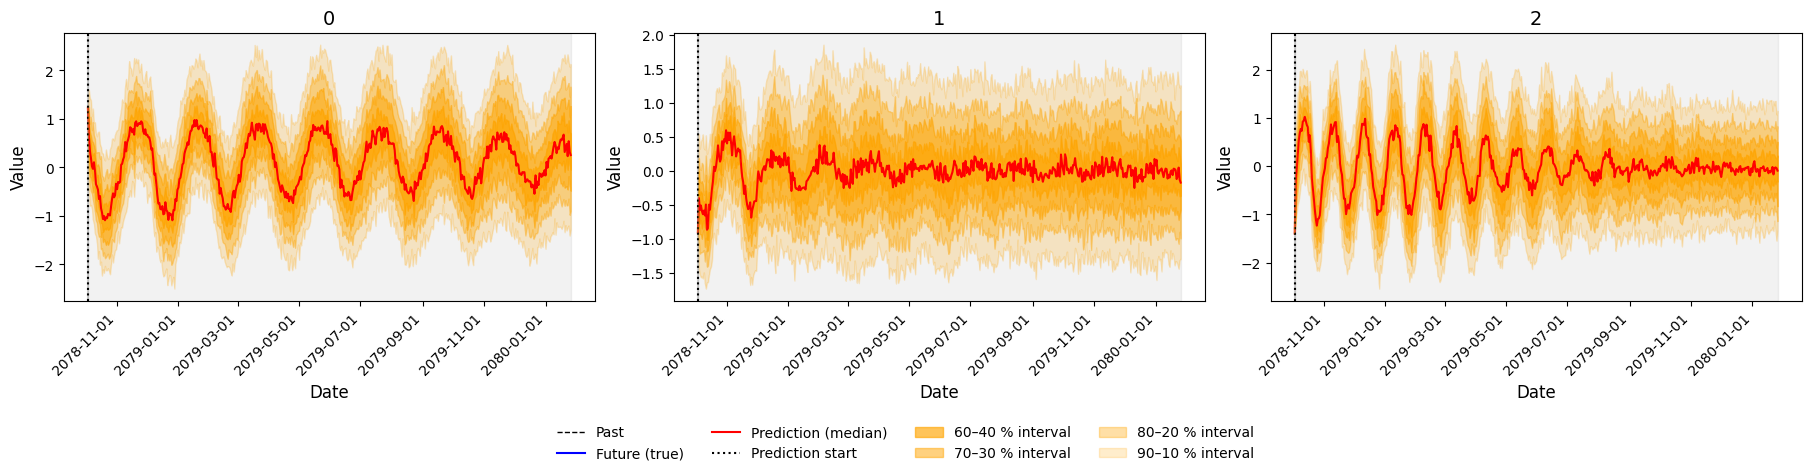

In [25]:
forecasts["ConQC"].plot_forecasts()

# Backtesting/Evaluation

comprehensive evaluation is available. Just cover a subset here

In [26]:
pipeline = ForecastingPipeline(
    model=Chronos,
    model_kwargs={
        "pretrained_model_name_or_path": f"amazon/chronos-bolt-tiny",
        "device_map": "cuda",
        "lead_times": lead_times,
        "name": f"Chronos-Bolt-tiny",
        "finetuning_schedule": ["Full"],
        "finetuning_adjust_pretrained_prediction_length": True,
        "finetuning_warmup_new_neurons": True,
    },
    postprocessors=[PostprocessorFastQR, PostprocessorEQC],
    postprocessor_kwargs=[{"name": "LinQC", "n_jobs": 4}, {"name": "ConQC","n_jobs": 4}],
    freq="D",
    output_dir=Path(".results/test/Chronos-Bolt-tiny"),
)

2025-09-30 19:26:53,789 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/models/Chronos-Bolt-tiny
2025-09-30 19:26:53,790 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-09-30 19:26:53,791 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-09-30 19:26:54,371 - INFO - chronos.py - Prepended 'new_neurons' for warm-up of new output rows.
2025-09-30 19:26:54,372 - INFO - chronos.py - Final fine-tuning schedule: new_neurons → full
2025-09-30 19:26:54,372 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/LinQC
2025-09-30 19:26:54,373 - INFO - base.py - Using the following output directory to store results: .results/test/Chronos-Bolt-tiny/postprocessors/ConQC


In [ ]:
results, execution_times  = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2070"), # select some test period
                            rolling_window_eval=False,
                            train=False, # zero shot
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train_val",
                            max_calibration_samples=500,
                            save_results=True)

In [38]:
results["Chronos-Bolt-tiny"].get_crps(mean_item_ids=True, mean_time=True, mean_lead_times=True)

,Mean CRPS
micro,0.797818


In [39]:
results["ConQC"].get_crps(mean_item_ids=True, mean_time=True, mean_lead_times=True)

,Mean CRPS
micro,0.670189


In [40]:
results["LinQC"].get_crps(mean_item_ids=True, mean_time=True, mean_lead_times=True)

,Mean CRPS
micro,0.693267


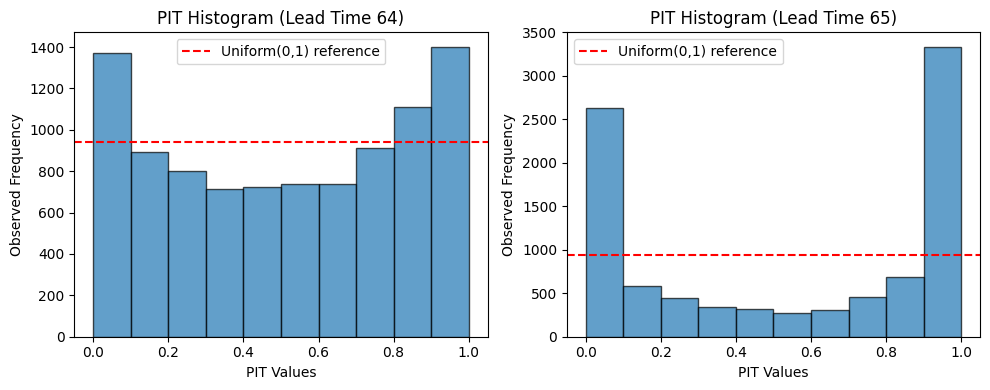

In [ ]:
# displaying overconfident forecasts
results["Chronos-Bolt-tiny"].plot_pit_histogram(lead_times=[64, 65])

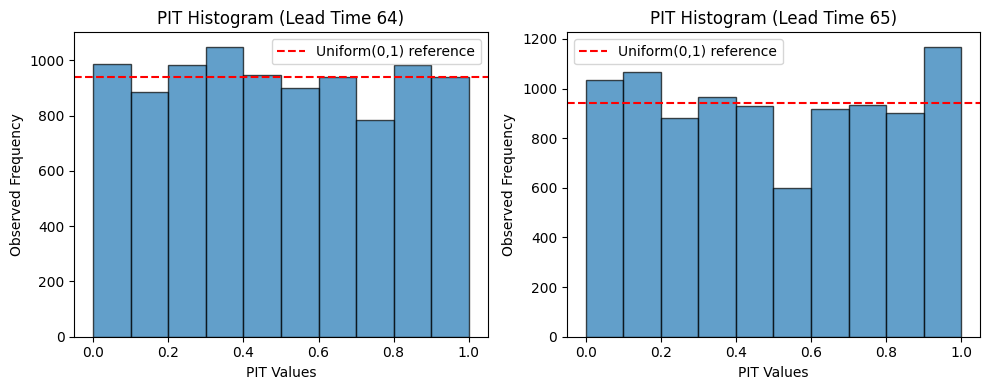

In [ ]:
# calibrated forecasts
results["ConQC"].plot_pit_histogram(lead_times=[64, 65])